# 1. Setup

Imports all libraries, detects GPU availability for TabPFN, and defines global constants used throughout the notebook.

**Key constants:**
- `random_state = 8` — fixed seed for reproducibility across all models and sampling.
- `features_UCLA` — the 26 engineered features supplied to every classifier (demographics, lifestyle, COVID-impact Likert items).
- `UCLA_cutoff = 22` — binary threshold on the UCLA Loneliness Scale-3 (UCLA-LS3); respondents scoring ≥ 22 are labelled *High Loneliness* [Deckx et al., 2014].
- `target_UCLA = "UCLA_High"` — the derived binary target column.

**References:**
- Deckx, L., Van Den Akker, M., & Buntinx, F. (2014). Risk factors for loneliness in patients with cancer. *European Journal of Oncology Nursing*, 18(5), 466–477.

In [1]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [2]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [3]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "UCLA"

features_UCLA = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]
target_UCLA = "UCLA_High"
vars_UCLA = ["ID", "Phase", "Year"]
UCLA_cutoff = 22

In [4]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

Loads the raw wide-format CSV, reshapes it from one row per respondent to one row per (respondent × wave), encodes categorical variables, and derives the binary target label.

**Pipeline steps:**
1. **Load** — reads `dataset.csv` with explicit NA tokens; 2,659 respondents × 106 columns.
2. **Reshape (wide → long)** — for each of the four survey phases (2020, 2021, 2022, 2024), the wave-suffix columns (`*_1` … `*_4`) are extracted and stacked, yielding 10,636 rows (2,659 × 4 phases).
3. **Missing data** — `HINCOME_group` is the only field with missing values (~17.5%); an `Income_Missing` indicator flag is created and the income value is imputed as 0 (the "missing" ordinal category), so no rows are dropped.
4. **Categorical encoding** — sex, marital status, and parental status are binarised; job type is one-hot encoded into five mutually exclusive columns (`Job_Employed`, `Job_Homemaker`, `Job_Student`, `Job_Unemployed`, `Job_Other`); income is kept as an ordinal integer (0–5).
5. **Target derivation** — `UCLA_High = 1` if `UCLA ≥ 22`, else 0 [Deckx et al., 2014].

**References:**
- Sugaya, N. et al. (2020–2024). Longitudinal survey dataset (Phases 1–4), Tokyo, Osaka, Hyogo, Fukuoka, Japan.
- Deckx, L., Van Den Akker, M., & Buntinx, F. (2014). Risk factors for loneliness. *European Journal of Oncology Nursing*, 18(5), 466–477.

In [5]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [6]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [7]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [8]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_UCLA] = (df_encoded["UCLA"] >= UCLA_cutoff).astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group", "UCLA"])
df_encoded = df_encoded[vars_UCLA + features_UCLA + [target_UCLA]]
print(f"Encoded: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded[target_UCLA].value_counts()}")

Encoded: (10636, 30)
Target distribution:
UCLA_High
1    7128
0    3508
Name: count, dtype: int64


# 3. Exploratory Data Analysis (EDA)

Produces three visualisations to understand the data before modelling:

1. **Descriptive statistics** (`df.describe()`) — checks ranges, means, and standard deviations for all 26 features and the target variable.
2. **Target distribution** — bar chart of Low vs. High Loneliness counts overall, and a stacked bar broken down by survey phase. High Loneliness (score ≥ 22) accounts for ~67% of all observations, indicating moderate class imbalance.
3. **Correlation heatmap** — Pearson correlations among all features and the target, revealing which predictors co-vary with loneliness.
4. **Feature distributions by class** — overlapping histograms for each feature split by Low/High Loneliness class, highlighting separation between classes.

In [9]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.670177
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.470171
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


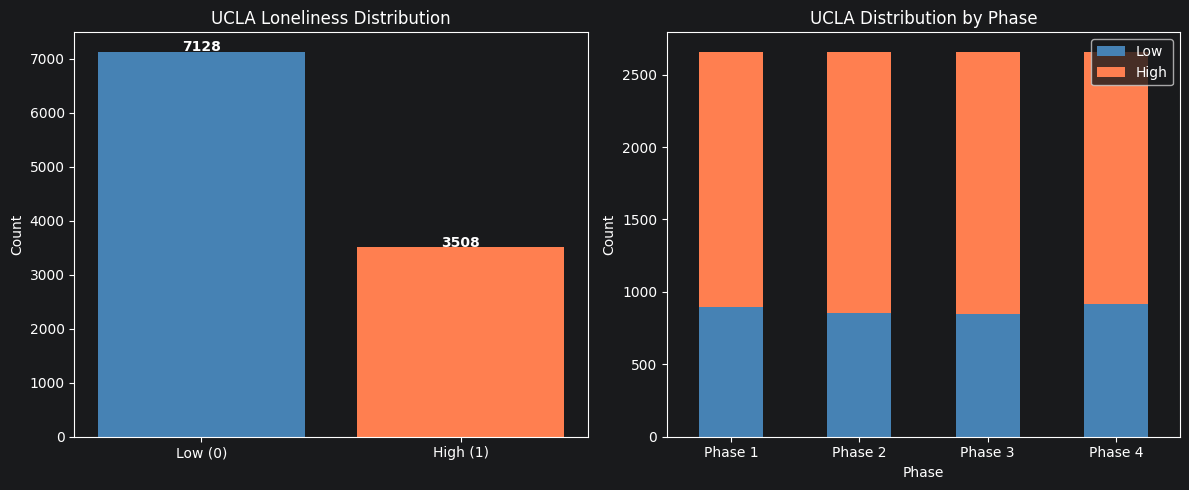

In [10]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_UCLA].value_counts()
axes[0].bar(["Low (0)", "High (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("UCLA Loneliness Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = df_encoded.groupby("Phase")[target_UCLA].value_counts().unstack(fill_value=0)
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("UCLA Distribution by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(["Low", "High"])
axes[1].set_xticklabels([f"Phase {i}" for i in range(1, 5)], rotation=0)

plt.tight_layout()
plt.show()

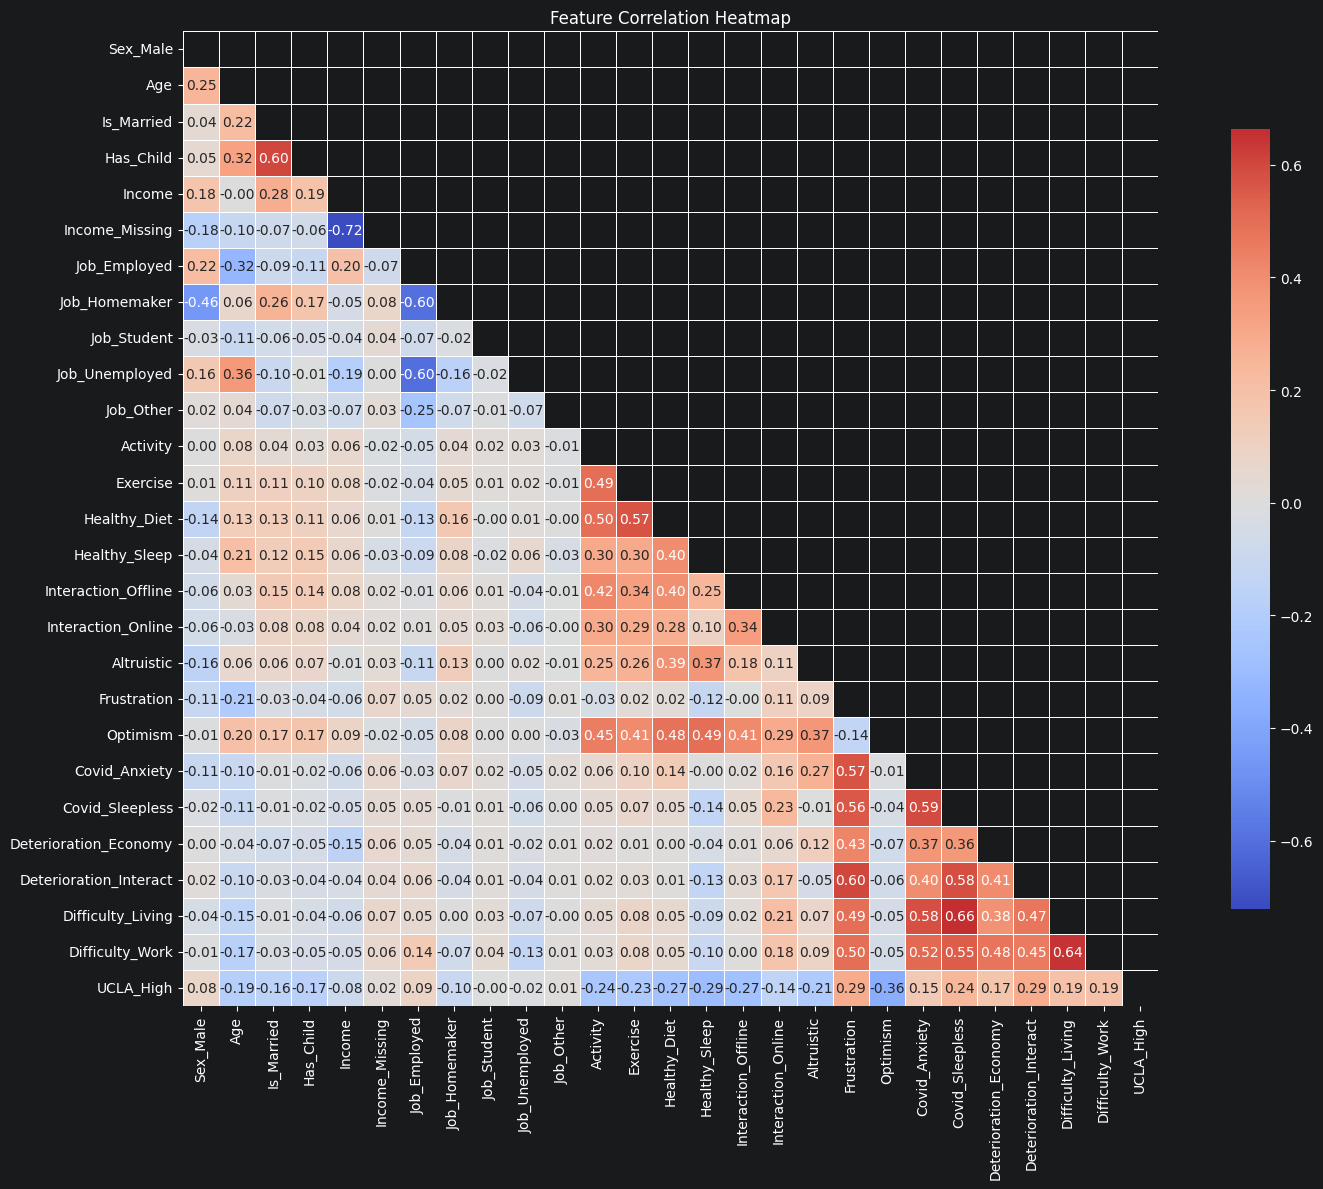

In [11]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_UCLA + [target_UCLA]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

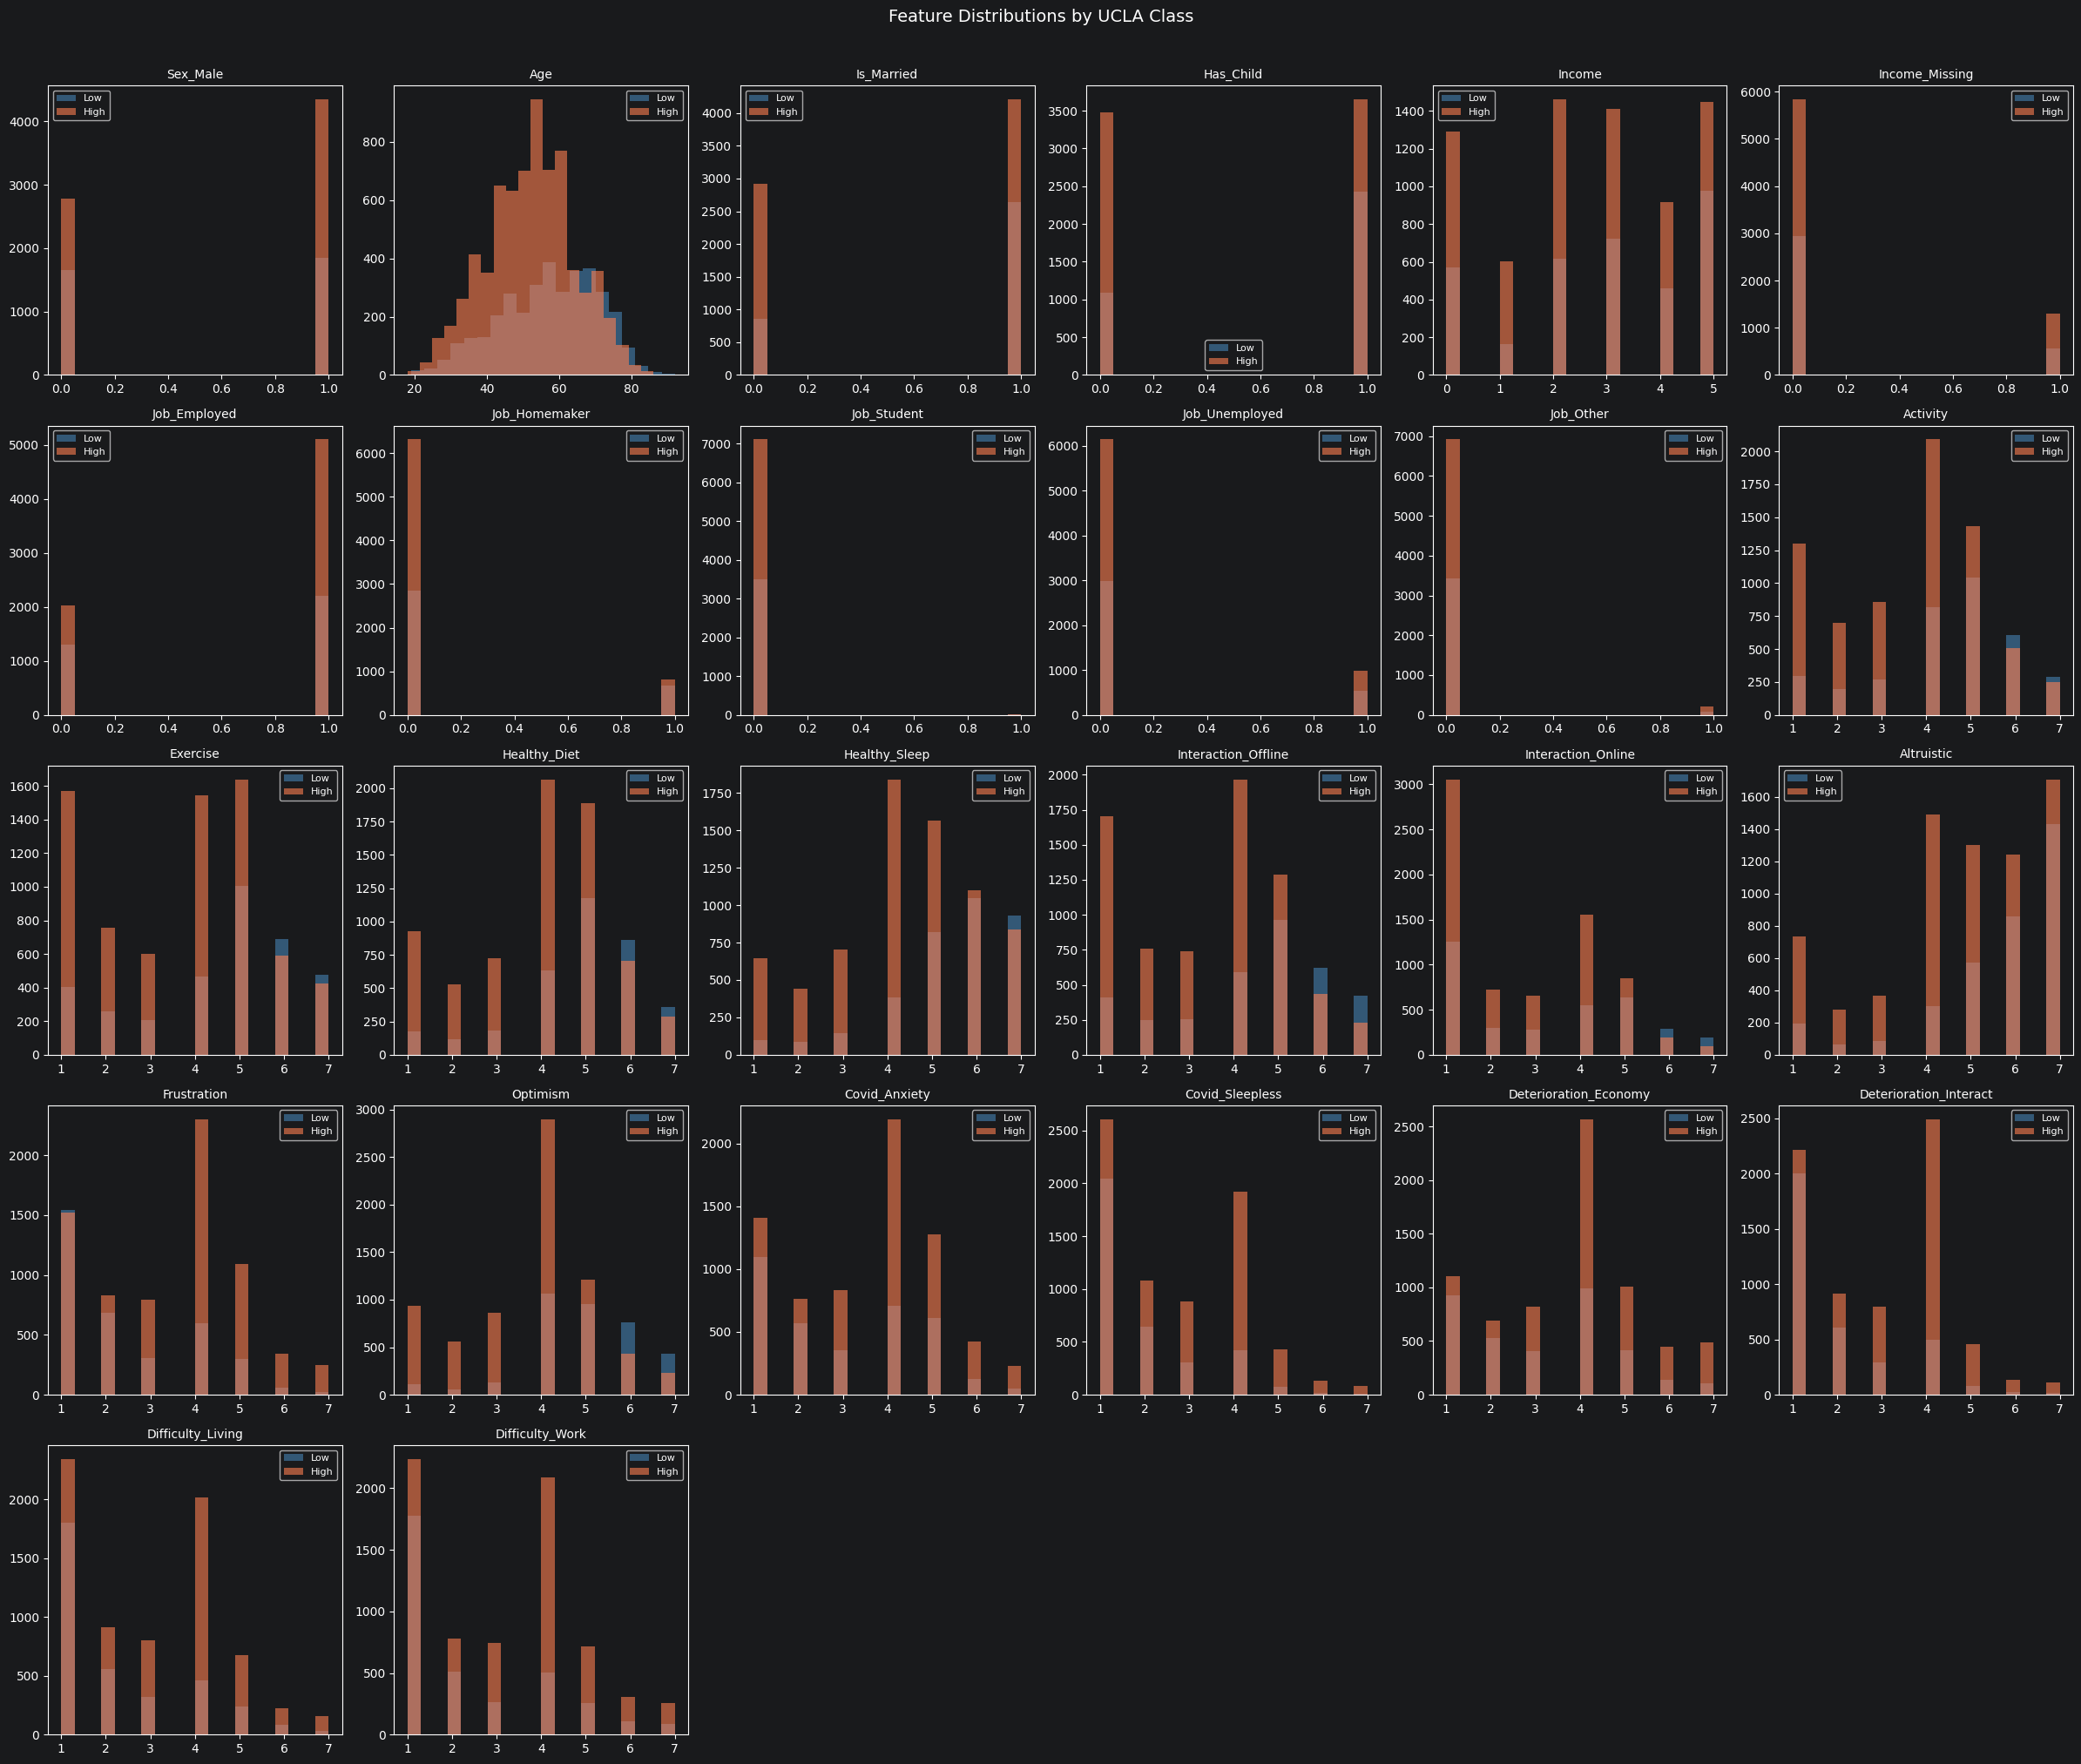

In [12]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_UCLA):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_UCLA] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label="Low" if label == 0 else "High")
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_UCLA), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by UCLA Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

Partitions the encoded dataset into training and test sets using a **temporal hold-out** strategy: Phases 1–3 (2020–2022) form the training set (n = 7,977); Phase 4 (2024) forms the held-out test set (n = 2,659).

This design simulates prospective deployment: the model is trained on pandemic-era data and evaluated on post-pandemic data from the same panel of respondents. It avoids data leakage from future waves into the training set and provides a realistic estimate of generalisation to the post-COVID period studied by Sugaya et al. (2024).

**Split summary:**
- `X_train` / `y_train`: 7,977 rows, 26 features
- `X_test` / `y_test`: 2,659 rows, 26 features

**Reference:**
- Sugaya, N. et al. (2024). Long-term mental health impacts of COVID-19: Findings from a four-wave longitudinal survey in Japan. *Journal of Affective Disorders.*

In [13]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_UCLA
X_train = df_train.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_train = df_train[target_UCLA]
X_test = df_test.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_test = df_test[target_UCLA]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
UCLA_High
1    5382
0    2595
Name: count, dtype: int64

Test target distribution:
UCLA_High
1    1746
0     913
Name: count, dtype: int64


# 5. Baseline Model Training

Trains seven classifiers on `X_train` using default hyperparameters and evaluates each on the held-out `X_test`. No hyperparameter tuning is performed at this stage — this establishes honest out-of-the-box baselines.

**Classifiers evaluated:**
| Model | Notes |
|---|---|
| Random Forest | Ensemble of decision trees; robust to noise |
| K-Nearest Neighbors | Distance-based; non-parametric |
| Decision Tree | Single tree; interpretable but prone to overfitting |
| Gaussian Naive Bayes | Probabilistic; assumes feature independence |
| Support Vector Machine | Margin-maximising; strong on high-dimensional data |
| MLP Classifier | Feed-forward neural network; default sklearn architecture |
| **TabPFN** | Prior-Data Fitted Network; meta-learned Transformer performing Bayesian inference in a single forward pass [Hollmann et al., 2023] |

**Metrics recorded per model:** Accuracy, F1-Score (weighted), ROC-AUC, training time, and inference time.

ROC-AUC is the primary selection criterion because the downstream SHAP and counterfactual pipelines consume predicted *probabilities*, not hard labels — a well-calibrated, discriminative model matters more than raw accuracy [Doshi-Velez & Kim, 2017].

**References:**
- Hollmann, N., Müller, S., Eggensperger, K., & Hutter, F. (2023). TabPFN: A transformer that solves small tabular classification problems in a second. *ICLR 2023.*
- Doshi-Velez, F., & Kim, B. (2017). Towards a rigorous science of interpretable machine learning. *arXiv:1702.08608.*

In [14]:
# Define all models with default hyperparameters
models = [
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(random_state=random_state)),
    ("MLP Classifier", MLPClassifier(random_state=random_state)),
    ("TabPFN", TabPFNClassifier(device=device, random_state=random_state))
]

In [15]:
# Train and evaluate all baseline models
results = []
trained_models = {}
cm_data = {}

for name, model in models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Train:    {format_time(train_time)}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Low', 'High'])}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test, y_pred)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  Random Forest (baseline)
  Accuracy: 0.7732
  F1-Score: 0.8349
  ROC AUC:  0.8317
  Train:    0.58s
  Predict:  0.03s

              precision    recall  f1-score   support

         Low       0.71      0.58      0.64       913
        High       0.80      0.87      0.83      1746

    accuracy                           0.77      2659
   macro avg       0.75      0.73      0.74      2659
weighted avg       0.77      0.77      0.77      2659


  K-Nearest Neighbors (baseline)
  Accuracy: 0.7537
  F1-Score: 0.8197
  ROC AUC:  0.7885
  Train:    0.00s
  Predict:  0.14s

              precision    recall  f1-score   support

         Low       0.67      0.56      0.61       913
        High       0.79      0.85      0.82      1746

    accuracy                           0.75      2659
   macro avg       0.73      0.71      0.72      2659
weighted avg       0.75      0.75      0.75      2659


  Decision Tree (baseline)
  Accuracy: 0.6826
  F1-Score: 0.7579
  ROC AUC:  0.6491
  Train:   

# 6. Results & Comparison

Displays the ranked performance table and confusion matrices for all seven classifiers.

**Key findings:**
- **TabPFN** achieves the highest ROC-AUC (0.8424), the highest F1-Score (0.8396), and competitive accuracy (0.7789) — the only model to lead all three quality metrics simultaneously.
- **SVM** achieves the highest raw accuracy (0.7792) and near-identical F1 (0.8397), but its ROC-AUC (0.7331) is substantially lower than TabPFN's, indicating weaker probability calibration.
- **Decision Tree** is the weakest model on all metrics, as expected for a single un-pruned tree.

The confusion matrices confirm that all models exhibit higher recall for the *High Loneliness* class (the majority class at ~67%), which is desirable in a clinical screening context where false negatives carry greater risk than false positives.

In [16]:
# Results table
display(df_results.sort_values("ROC AUC", ascending=False))

,Model,Accuracy,F1-Score,ROC AUC,Train Time (s),Test Time (s)
6,TabPFN,0.778864,0.839607,0.842432,0.840013,7.732667
0,Random Forest,0.773223,0.834930,0.831728,0.582228,0.025143
5,MLP Classifier,0.771719,0.828094,0.818569,1.223328,0.001179
3,Gaussian Naive Bayes,0.746145,0.801646,0.810868,0.002136,0.000726
1,K-Nearest Neighbors,0.753667,0.819708,0.788546,0.001714,0.143002
4,Support Vector Machine,0.779240,0.839661,0.733139,1.048585,0.421110
2,Decision Tree,0.682587,0.757889,0.649140,0.032044,0.000731


In [17]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=["Predicted Low", "Predicted High"],
        y=["Actual Low", "Actual High"],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale="Viridis"
    )
    fig_cm.update_layout(title_text=f"Confusion Matrix (Baseline): {name}",
                         yaxis=dict(autorange="reversed"), height=350)
    fig_cm.show()

# 7. Save Models & Results

Serialises all trained models (`.joblib`), the baseline comparison table (`baseline_comparison_results.csv`), and the train/test splits (`X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`) to disk.

These artifacts are consumed by the full XAI pipeline notebook (`additional_cfx.ipynb`) to avoid re-training. The TabPFN model file (`models/tabpfn.joblib`) is the primary artifact: it is loaded in subsequent notebooks via `LOAD_SAVED_MODEL = True` to skip the ≈1-second training step on re-runs.

In [18]:
# Save all baseline models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    save_path = f"models/baseline_{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/baseline_comparison_results.csv", index=False)
print("\nBaseline comparison results saved to models/baseline_comparison_results.csv")

# Save training data
X_train.to_csv("artifacts/X_train.csv", index=False)
X_test.to_csv("artifacts/X_test.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)
print("Training/test data saved.")

FileNotFoundError: [Errno 2] No such file or directory: 'models/baseline_random_forest.joblib'